# Clustering Analysis: K-Means vs AgglomerativeClustering vs GMM

This notebook compares K-Means, AgglomerativeClustering, and Gaussian Mixture Model (GMM) clustering methods on the transposed variant mean data.
We evaluate clustering quality using:
- Silhouette Coefficient (higher is better, range: -1 to 1)


For k = 3, 5, 7 clusters

In [28]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from os.path import join
from pathlib import Path
import numpy as np
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')

from sklearn.manifold import TSNE


In [30]:
from mylib import genomes

In [31]:
root_dir = join(Path.home(),"projects/cp_als/populations")

## Data Preparation
Load and prepare the same data as in the original notebook (cell 5-7)

In [32]:
population_name = "CHB"
genome_ids = genomes[population_name]
df = pd.read_csv(join(root_dir,f"output/{population_name}/all.csv"))
df.head()

,#CHROM,POS,REF,ALT,FILTER,INFO,FORMAT,NA18605,NA18573,NA18627,...,INFO:AF,INFO:EAS_AF,INFO:EUR_AF,INFO:AFR_AF,INFO:AMR_AF,INFO:SAS_AF,INFO:VT,INFO:NS,INFO:EX_TARGET,gene
0,1,11014326,A,T,PASS,AC=3;AN=5096;DP=25659;AF=0;EAS_AF=0;EUR_AF=0;A...,GT,0,0,0,...,0.0,0.00,0.00,0.0,0.00,0.00,SNP,2548,NaN,TARDBP
1,1,11014327,T,G,PASS,AC=3;AN=5096;DP=25613;AF=0;EAS_AF=0;EUR_AF=0;A...,GT,0,0,0,...,0.0,0.00,0.00,0.0,0.00,0.00,SNP,2548,NaN,TARDBP
2,1,11014361,G,T,PASS,AC=1;AN=5096;DP=24038;AF=0;EAS_AF=0;EUR_AF=0;A...,GT,0,0,0,...,0.0,0.00,0.00,0.0,0.00,0.00,SNP,2548,NaN,TARDBP
3,1,11014464,A,G,PASS,AC=1;AN=5096;DP=24237;AF=0;EAS_AF=0;EUR_AF=0;A...,GT,0,0,0,...,0.0,0.00,0.00,0.0,0.00,0.00,SNP,2548,NaN,TARDBP
4,1,11014525,A,G,PASS,AC=517;AN=5096;DP=25686;AF=0.1;EAS_AF=0.21;EUR...,GT,1,0,1,...,0.1,0.21,0.02,0.1,0.04,0.12,SNP,2548,NaN,TARDBP


In [33]:
sdf = df[genome_ids + ["gene"]]
sdf.head()

,NA18605,NA18573,NA18627,NA18747,NA18616,NA18596,NA18552,NA18648,NA18626,NA18619,...,NA18537,NA18640,NA18618,NA18595,NA18633,NA18643,NA18535,NA18558,NA18647,gene
0,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,TARDBP
1,0,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,TARDBP
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,TARDBP
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,TARDBP
4,1,0,1,1,0,0,0,0,1,0,...,1,0,0,0,1,0,0,0,1,TARDBP


In [34]:
# Cell 5: Create aggregated dataframe
adf = pd.DataFrame(columns=genomes.keys())
for population_name in genomes:
    genome_ids = genomes[population_name]
    df = pd.read_csv(join(root_dir,f"output/{population_name}/all.csv"))
    df = df[genomes[population_name]+["gene"]]
    variant_mean = df.groupby(['gene']).sum().mean(axis=1)
    #variant_mean = df.groupby(['gene']).mean().mean(axis=1)
    adf[population_name] = variant_mean

In [35]:
# Cell 7: Transpose the dataframe (populations as rows, genes as columns)
tdf = adf.transpose()

# Apply StandardScaler to normalize the features
scaler = StandardScaler()
tdf_scaled = pd.DataFrame(
    scaler.fit_transform(tdf),
    index=tdf.index,
    columns=tdf.columns
)

# Use the scaled data for clustering
tdf = tdf_scaled

print(f"Data shape: {tdf.shape}")
print(f"Populations (samples): {tdf.shape[0]}")
print(f"Genes (features): {tdf.shape[1]}")
print(f"Data has been standardized (mean=0, std=1)")
tdf.head()

Data shape: (25, 36)
Populations (samples): 25
Genes (features): 36
Data has been standardized (mean=0, std=1)


gene,ALS2,ANG,ATXN2,C19ORF12,C9ORF72,CHCHD10,CHMP2B,CHRNA3,CREST,DAO,...,SOD1,SPG11,SQSTM1,TAF15,TARDBP,TUBA4A,VAPB,VCP,hnRNPA2B1,hnRNPa1
ACB,1.102645,1.128434,1.636243,1.102311,1.395117,1.143710,-1.092209,0.348594,1.521314,1.582708,...,1.374191,1.041270,1.443258,0.286015,1.286350,2.189955,1.213263,0.184496,0.858847,1.203419
ASW,1.200857,1.138543,1.307655,1.629316,0.268797,1.201626,-0.378954,0.424317,0.915024,1.370488,...,1.281477,0.834331,1.043324,0.887077,1.388055,1.245102,0.599634,0.566145,0.959160,1.007382
BEB,-0.830602,-0.770339,-0.590080,-0.520505,0.026426,-0.784608,-0.389150,-0.533504,-0.200352,-0.439375,...,-0.809988,0.049136,-0.719947,-0.279352,-0.455570,-0.253987,-1.316458,0.369803,-1.014501,-0.435663
CDX,0.374427,-1.994538,-0.801093,-0.713994,-1.298152,-1.426053,0.202522,-0.436050,-0.412203,-0.550772,...,-0.804526,0.753611,-0.701127,0.291097,-0.473177,-0.785500,0.279032,-1.961982,-0.524822,0.129242
CHB,-0.289140,-1.219776,-0.816597,-0.866698,-1.688381,-1.364592,-1.070306,-0.091384,-0.323092,-0.782569,...,-0.645658,0.590891,-0.663827,0.975819,-0.420319,-0.132788,-1.015357,-1.691131,-0.185591,0.506971


## Clustering Analysis

We'll apply both K-Means and Hierarchical clustering for k=3, 5, 7 clusters and evaluate each using three metrics.

In [36]:
def evaluate_clustering(data, labels, method_name, k):
    """
    Evaluate clustering quality using three metrics.
    
    Parameters:
    - data: feature matrix
    - labels: cluster labels
    - method_name: name of clustering method
    - k: number of clusters
    
    Returns:
    - Dictionary with evaluation metrics
    """
    silhouette = silhouette_score(data, labels)

    
    return {
        'Method': method_name,
        'K': k,
        'Silhouette Coefficient': silhouette,
    }

In [37]:
import numpy as np
import pandas as pd

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# -----------------------------
# Metric evaluation (robust)
# -----------------------------
def compute_metrics(X, labels):
    """
    Returns silhouette coefficient.
    Handles degenerate cases (e.g., 1 cluster in a bootstrap sample).
    """
    unique = np.unique(labels)
    if len(unique) < 2 or X.shape[0] < 3:
        # silhouette is undefined / unstable with <2 clusters or too few points
        return np.nan

    sil = silhouette_score(X, labels)
    return sil


# -----------------------------
# Bootstrap runner
# -----------------------------
def bootstrap_clustering_metrics(
    X,
    k_values=(3, 5, 7, 9),
    n_boot=10,
    base_seed=42,
    scale=False,
    kmeans_n_init=10,
    gmm_n_init=10,
):
    """
    Bootstraps rows of X (sampling with replacement) to estimate variability
    for KMeans, AgglomerativeClustering, and GMM fairly.

    Returns:
      runs_df: per-run results
      summary_df: mean/std/95% CI for plotting
    """
    X = np.asarray(X)

    # optional scaling (often good if feature scales differ)
    if scale:
        X = StandardScaler().fit_transform(X)

    n = X.shape[0]
    rng = np.random.default_rng(base_seed)

    methods = ["K-Means", "AgglomerativeClustering", "Gaussian Mixture Model"]
    runs = []

    for k in k_values:
        print(f"\n=== k = {k} ===")

        for run in range(n_boot):
            # Bootstrap sample indices (same for ALL methods => fair)
            # Seeded by base rng so it's reproducible.
            idx = rng.integers(0, n, size=n)
            Xb = X[idx]

            # Also give each run a deterministic seed for stochastic methods
            run_seed = base_seed + run

            # ---- K-Means
            km = KMeans(n_clusters=k, random_state=run_seed, n_init=kmeans_n_init)
            km_labels = km.fit_predict(Xb)
            km_sil = compute_metrics(Xb, km_labels)
            runs.append({
                "Method": "K-Means",
                "K": k,
                "Run": run,
                "Seed": run_seed,
                "Silhouette Coefficient": km_sil,
            })

            # ---- Agglomerative (deterministic on Xb, but Xb varies => CI meaningful)
            agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
            agg_labels = agg.fit_predict(Xb)
            agg_sil = compute_metrics(Xb, agg_labels)
            runs.append({
                "Method": "AgglomerativeClustering",
                "K": k,
                "Run": run,
                "Seed": run_seed,
                "Silhouette Coefficient": agg_sil,
            })

            # ---- GMM
            gmm = GaussianMixture(n_components=k, random_state=run_seed, n_init=gmm_n_init)
            gmm_labels = gmm.fit_predict(Xb)
            gmm_sil = compute_metrics(Xb, gmm_labels)
            runs.append({
                "Method": "Gaussian Mixture Model",
                "K": k,
                "Run": run,
                "Seed": run_seed,
                "Silhouette Coefficient": gmm_sil,
            })

        print(f"Completed {n_boot} bootstrap runs for k={k} across all methods.")

    runs_df = pd.DataFrame(runs)

    # Summaries for plotting mean ± 95% CI (ignore NaNs safely)
    def summarize(g):
        n_eff_s = g["Silhouette Coefficient"].notna().sum()
        mean_s  = g["Silhouette Coefficient"].mean()
        std_s   = g["Silhouette Coefficient"].std(ddof=1) if n_eff_s > 1 else 0.0
        ci_s    = 1.96 * std_s / np.sqrt(n_eff_s) if n_eff_s > 1 else 0.0

        return pd.Series({
            "n_runs_total": len(g),
            "n_eff_silhouette": n_eff_s,
            "Silhouette Mean": mean_s,
            "Silhouette Std": std_s,
            "Silhouette 95CI": ci_s,
        })

    summary_df = runs_df.groupby(["Method", "K"], as_index=False).apply(summarize)

    return runs_df, summary_df

In [38]:
X = tdf.values

runs_df, summary_df = bootstrap_clustering_metrics(
    X,
    k_values=[3, 5, 7],
    n_boot=10,
    base_seed=42,
    scale=False  # set True if feature scales differ a lot
)


=== k = 3 ===
Completed 10 bootstrap runs for k=3 across all methods.

=== k = 5 ===
Completed 10 bootstrap runs for k=5 across all methods.

=== k = 7 ===
Completed 10 bootstrap runs for k=7 across all methods.


In [39]:
import os
import numpy as np
import matplotlib.pyplot as plt

def plot_silhouette_selection_poster(
    summary_df,
    k_values=(3, 5, 7),
    highlight_k=5,
    out_dir="plots",
    filename="silhouette_k_selection.png",
    title="Clustering Comparison: Silhouette Coefficient",
):
    os.makedirs(out_dir, exist_ok=True)

    # Poster-friendly, consistent method colors
    colors = {
        "K-Means": "#1F4E79",                  # deep blue
        "AgglomerativeClustering": "#C00000",  # crimson
        "Gaussian Mixture Model": "#2E7D32"    # deep green
    }
    methods = ["K-Means", "AgglomerativeClustering", "Gaussian Mixture Model"]

    # x positions are discrete categories
    x = np.arange(len(k_values))

    fig, ax = plt.subplots(figsize=(12, 6))
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    # --- highlight the best k column (vertical band)
    if highlight_k in k_values:
        hk_idx = k_values.index(highlight_k)
        ax.axvspan(hk_idx - 0.5, hk_idx + 0.5, alpha=0.12, zorder=0)

    # jitter offsets so methods don’t overlap
    offsets = {
        "K-Means": -0.18,
        "AgglomerativeClustering": 0.00,
        "Gaussian Mixture Model": 0.18
    }

    for method in methods:
        mdf = summary_df[(summary_df["Method"] == method) &
                         (summary_df["K"].isin(k_values))].copy()
        mdf = mdf.set_index("K").loc[list(k_values)].reset_index()

        y = mdf["Silhouette Mean"].values
        yerr = mdf["Silhouette 95CI"].values

        x_method = x + offsets[method]

        # point + CI (no line)
        ax.errorbar(
            x_method, y,
            yerr=yerr,
            fmt="o",
            markersize=11,
            capsize=6,
            capthick=2,
            elinewidth=2.5,
            color=colors[method],
            alpha=0.95,
            label=method,
            markeredgecolor="black",
            markeredgewidth=0.8,
            zorder=3
        )

    # --- annotate “best k”
    if highlight_k in k_values:
        hk_idx = k_values.index(highlight_k)

        # place annotation slightly above the max mean among methods at highlight_k
        hk_rows = summary_df[(summary_df["K"] == highlight_k) &
                             (summary_df["Method"].isin(methods))]
        y_top = (hk_rows["Silhouette Mean"] + hk_rows["Silhouette 95CI"]).max()

        ax.annotate(
            "Best k (max silhouette)",
            xy=(hk_idx, y_top),
            xytext=(hk_idx, y_top + 0.05),
            ha="center",
            fontsize=13,
            fontweight="bold",
            arrowprops=dict(arrowstyle="->", lw=2)
        )

    # axes formatting
    ax.set_xticks(x)
    ax.set_xticklabels([str(k) for k in k_values], fontsize=13, fontweight="bold")
    ax.set_xlabel("Number of Clusters (k)", fontsize=14, fontweight="bold")
    ax.set_ylabel("Silhouette Coefficient (Higher is Better)\nMean ± 95% CI (bootstrap)",
                  fontsize=13, fontweight="bold")

    ax.grid(True, axis="y", alpha=0.25)
    ax.tick_params(axis="y", labelsize=12)

    ax.set_title(title, fontsize=16, fontweight="bold", pad=12)

    ax.legend(frameon=True, fontsize=12, loc="best")

    plt.tight_layout()

    out_path = os.path.join(out_dir, filename)
    plt.savefig(out_path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.show()

    print(f"Saved: {out_path}")
    return out_path

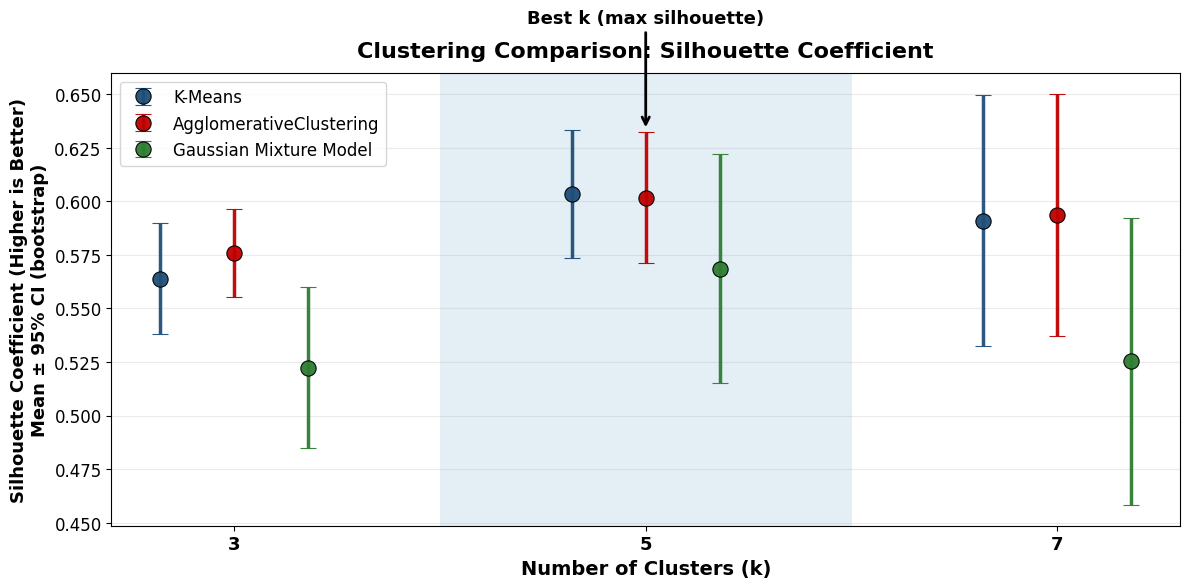

Saved: plots/silhouette_k_selection.png


'plots/silhouette_k_selection.png'

In [40]:
plot_silhouette_selection_poster(
    summary_df=summary_df,
    k_values=[3, 5, 7],
    highlight_k=5,
    out_dir="plots",
    filename="silhouette_k_selection.png"
)